# BiPlane Challenge

In [1]:
try:
    import mat73
except ImportError:
    pass

from pathlib import Path

import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

In [2]:
path = "~/jobs/deploy/decode"
path = Path(path).expanduser()
import sys

sys.path.insert(0, str(path))

In [3]:
import decode
import decode.evaluation.optimize
from decode.neuralfitter.train import setup_cfg
import decode.neuralfitter.inference.functional as infer_func
print(decode.__file__)


%config InlineBackend.figure_format='retina'

/home/riesgroup/jobs/deploy/decode/decode/__init__.py


In [4]:
path_out = "/mnt/t1ries/users/Lucas/Manuscripts/plex/raw/biplane_challenge"
path_out = Path(path_out)

path_smap = "/mnt/t1ries/decode/fit/biplane_challenge/"
path_smap = Path(path_smap)

In [5]:
snr = pd.DataFrame({"snr": ["low", "high"]})
density = pd.DataFrame({"density": ["low", "high"]})
# ds_type = pd.DataFrame({"type": ["train"]})
ds_type = pd.DataFrame({"type": ["train", "test"]})

scen = pd.merge(snr, density, how="cross")
scen = pd.merge(scen, ds_type, how="cross")
scen["dataset"] = None
scen["path_data"] = None
scen["path_frame"] = None
scen["path_em"] = None
scen["path_model"] = None

scen

,snr,density,type,dataset,path_data,path_frame,path_em,path_model
0,low,low,train,None,None,None,None,None
1,low,low,test,None,None,None,None,None
2,low,high,train,None,None,None,None,None
3,low,high,test,None,None,None,None,None
4,high,low,train,None,None,None,None,None
5,high,low,test,None,None,None,None,None
6,high,high,train,None,None,None,None,None
7,high,high,test,None,None,None,None,None


In [6]:
# construct path
def get_path(row):
    if row["type"] == "test":
        match row["snr"], row["density"]:
            case "high", "low":
                return "MT1_N1_LD"
            case "high", "high":
                return "MT2_N1_HD"
            case "low", "low":
                return "MT3_N2_LD"
            case "low", "high":
                return "MT4_N2_HD"
            case _:
                raise ValueError(f"Unknown combination: {row['snr']}, {row['density']}")

    path = "MT0_"
    match row["snr"]:
        case "high":
            path += "N1_"
        case "low":
            path += "N2_"

    match row["density"]:
        case "high":
            path += "HD"
        case "low":
            path += "LD"

    return path

scen["dataset"] = scen.apply(get_path, axis=1)
scen.set_index(["snr", "density", "type"], inplace=True)

# patch
# scen.loc[("low", "low", "test"), "dataset"] = None  # broken zip

scen


dataset path_data path_frame path_em path_model
snr  density type                                                    
low  low     train  MT0_N2_LD      None       None    None       None
             test   MT3_N2_LD      None       None    None       None
     high    train  MT0_N2_HD      None       None    None       None
             test   MT4_N2_HD      None       None    None       None
high low     train  MT0_N1_LD      None       None    None       None
             test   MT1_N1_LD      None       None    None       None
     high    train  MT0_N1_HD      None       None    None       None
             test   MT2_N1_HD      None       None    None       None

In [13]:

# fill actual paths as well as model
path_model_base = "~/decode_storage/dev/lucas/training"
path_model_base = Path(path_model_base).expanduser()

path_data_base = "~/decode_scratch/challenge/"
path_data_base = Path(path_data_base).expanduser()

# scen = scen.copy()
# scen.drop("test", level="type", inplace=True)

# add simulated data row
# scen.loc[("high", "high", "sim"), "path_data"] = path_data_base / "MT0_N1_HD_sim"
# scen.at[("high", "high", "sim"), "em"] = scen.loc[("high", "high", "train"), "em"]

scen["path_data"] = scen["dataset"].apply(lambda p: (path_data_base / p) if p is not None else None)
# scen["dataset"] = scen.path_data.apply(lambda p: p.stem if p is not None else None)

scen.loc["high", "path_model"] = path_model_base / "biplane_challenge/2024-02-15_11-19-17-430422"  # 10 nm
scen.loc[("high", slice(None), "test"), "path_model"] = path_model_base / "biplane_challenge_hsnr_testset/2024-04-04_10-32-19-989029"
# scen.loc["high", "path_model"] = path_model_base / "biplane_challenge/2024-02-29_14-06-18-705816"  # from beads
scen.loc["low", "path_model"] = path_model_base / "biplane_challenge/2024-02-15_11-19-17-381319"  # 10 nm
# scen.loc["low", "path_model"] = path_model_base / "biplane_challenge/2024-02-29_14-03-45-807371"  # from beads

scen["path_frame"] = scen["path_data"].apply(lambda p: next(iter(p.glob("*.tif"))) if p is not None else None)

# for all train, fill path_em
scen["path_em"] = scen["path_data"].apply(lambda p: p / "activations.csv" if p is not None else None)
scen.loc[(slice(None), slice(None), "test"), "path_em"] = None

scen

dataset  \
snr  density type               
low  low     train  MT0_N2_LD   
             test   MT3_N2_LD   
     high    train  MT0_N2_HD   
             test   MT4_N2_HD   
high low     train  MT0_N1_LD   
             test   MT1_N1_LD   
     high    train  MT0_N1_HD   
             test   MT2_N1_HD   

                                                            path_data  \
snr  density type                                                       
low  low     train  /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test   /home/riesgroup/decode_scratch/challenge/MT3_N...   
     high    train  /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test   /home/riesgroup/decode_scratch/challenge/MT4_N...   
high low     train  /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test   /home/riesgroup/decode_scratch/challenge/MT1_N...   
     high    train  /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test   /home/riesgroup/decode_scratch/challenge/MT2_N...   

                                                           path_frame  \
snr  density type                                                       
low  low     train  /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test   /home/riesgroup/decode_scratch/challenge/MT3_N...   
     high    train  /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test   /home/riesgroup/decode_scratch/challenge/MT4_N...   
high low     train  /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test   /home/riesgroup/decode_scratch/challenge/MT1_N...   
     high    train  /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test   /home/riesgroup/decode_scratch/challenge/MT2_N...   

                                                              path_em  \
snr  density type                                                       
low  low     train  /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test                                                None   
     high    train  /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test                                                None   
high low     train  /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test                                                None   
     high    train  /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test                                                None   

                                                           path_model  \
snr  density type                                                       
low  low     train  /home/riesgroup/decode_storage/dev/lucas/train...   
             test   /home/riesgroup/decode_storage/dev/lucas/train...   
     high    train  /home/riesgroup/decode_storage/dev/lucas/train...   
             test   /home/riesgroup/decode_storage/dev/lucas/train...   
high low     train  /home/riesgroup/decode_storage/dev/lucas/train...   
             test   /home/riesgroup/decode_storage/dev/lucas/train...   
     high    train  /home/riesgroup/decode_storage/dev/lucas/train...   
             test   /home/riesgroup/decode_storage/dev/lucas/train...   

                                                                   em em_out  
snr  density type                                                             
low  low     train  EmitterSet
::num emitters: 24938
::xy unit: nm...   None  
             test                                                None   None  
     high    train  EmitterSet
::num emitters: 31612
::xy unit: nm...   None  
             test                                                None   None  
high low     train  EmitterSet
::num emitters: 24938
::xy unit: nm...   None  
             test                                                None   None  
     high    train  EmitterSet
::num emitters: 31612
::xy unit: nm...   None  
             test                                       

In [11]:
scen["em"] = None
scen["em_out"] = None

for i, (idx, row) in enumerate(scen.iterrows()):
    if row["path_em"] is None:
        continue

    em, *_ = decode.io.emitter.load_challenge(row["path_data"] / "activations.csv")
    em = decode.EmitterSet(**em, xy_unit="nm", px_size=(100., 100.))

    # convert challenge to decode standard
    # em.xyz = em.xyz[:, [1, 0, 2]]
    # em.xyz_px = em.xyz_px - torch.tensor([[1., 0., 0.]])
    # em.xyz_px[:, 2] *= -1
    # em.xyz_nm += torch.tensor([ 5.4507,  5.4528, 10.4507])
    # em.frame_ix -= 1
    scen["em"].iloc[i] = em

In [12]:
scen_smap = pd.DataFrame(index=scen.index)
scen_smap["algorithm"] = "SMAP"
scen_smap.set_index("algorithm", append=True, inplace=True)
scen_smap["path_em"] = None
scen_smap["em_out"] = None


scen_smap.loc[("high", "low", "train"), "path_em"] = path_smap / "MT0_N1_LD"/ "JRTEST_sequence-MT0.N1.LD-BP-Exp-as-stack_sml.mat" #"sequence-MT0.N1.LD-BP-Exp-as-stack_beads10nm_2_sml.mat"

for i, r in scen_smap.iterrows():
    if r["path_em"] is None:
        continue

    em, *_ = decode.io.emitter.load_smap(r["path_em"], return_raw=False)
    em = decode.EmitterSet(**em, xy_unit="nm", px_size=(100., 100.))
    scen_smap.at[i, "em_out"] = em

scen_smap["em"] = scen["em"]
scen_smap

path_em  \
snr  density type  algorithm                                                      
low  low     train SMAP                                                    None   
             test  SMAP                                                    None   
     high    train SMAP                                                    None   
             test  SMAP                                                    None   
high low     train SMAP       /mnt/t1ries/decode/fit/biplane_challenge/MT0_N...   
             test  SMAP                                                    None   
     high    train SMAP                                                    None   
             test  SMAP                                                    None   

                                                                         em_out  \
snr  density type  algorithm                                                      
low  low     train SMAP                                                    None   
             test  SMAP                                                    None   
     high    train SMAP                                                    None   
             test  SMAP                                                    None   
high low     train SMAP       EmitterSet
::num emitters: 166862
::xy unit: n...   
             test  SMAP                                                    None   
     high    train SMAP                                                    None   
             test  SMAP                                                    None   

                                                                             em  
snr  density type  algorithm                                                     
low  low     train SMAP       EmitterSet
::num emitters: 24938
::xy unit: nm...  
             test  SMAP                                                    None  
     high    train SMAP       EmitterSet
::num emitters: 31612
::xy unit: nm...  
             test  SMAP                                                    None  
high low     train SMAP       EmitterSet
::num emitters: 24938
::xy unit: nm...  
             test  SMAP                                                    None  
     high    train SMAP       EmitterSet
::num emitters: 31612
::xy unit: nm...  
             test  SMAP                                                    None

In [18]:
sorted(scen.iloc[-1].path_data.glob("*"))

[PosixPath('/home/riesgroup/decode_scratch/challenge/MT2_N1_HD/MT2_N1_HD_decode_fit.h5'),
 PosixPath('/home/riesgroup/decode_scratch/challenge/MT2_N1_HD/MT2_N1_HD_decode_fit_filtered.h5'),
 PosixPath('/home/riesgroup/decode_scratch/challenge/MT2_N1_HD/sequence-MT2.N1.HD-BP-Exp-as-stack.tif')]

# Fully Automatic Inference

In [19]:
# patch
def patch_load(path_cfg):
    return path_cfg

def frame_load(path):
    f = decode.io.frames.load_tif(path)
    if (f.shape[-2] != 64) or (f.shape[-1] != 128):
        raise ValueError(f"Frame shape {f.shape} not supported")

    f = [f[..., :64], f[..., 64:]]
    # f = [f[1], f[0]]
    return f

In [20]:
trafo = None
frame_crop = (64, 64)

em_decode = []

for i, s in scen.reset_index().iterrows():

    if s["path_model"] is None or s["path_data"] is None:
        em_decode.append(None)
        continue

    path_frame = next(s["path_data"].glob("*.tif"))
    frames = frame_load(path_frame)

    path_model = Path(s["path_model"])
    path_ckpt = sorted(path_model.glob("*.ckpt"))[0]
    path_cfg = path_model / "param_run.yaml"

    cfg = patch_load(path_cfg)

    em_out, logger = infer_func.infer(
        frames,
        mode="multi",
        frame_crop=frame_crop,
        cfg=cfg,
        model=path_ckpt,
        trafo=trafo,
        mode_camera="cameras",
        logger="debug",
    )

    em_decode.append(em_out)

scen_decode = scen.copy()
scen_decode["em_out"] = em_decode
scen_decode["algorithm"] = "DECODE"
scen_decode.set_index("algorithm", append=True, inplace=True)

2024-04-05 10:35:53 [info     ] Running experimental function `infer` tested=False
2024-04-05 10:35:53 [info     ] Running experimental function `load_model` tested=False
2024-04-05 10:35:56 [info     ] Setting up frame pre-processing in multi-camera mode.
2024-04-05 10:35:56 [info     ] Offsets as specified in config. offset=[(0, 0), (0, 0)]
2024-04-05 10:35:57 [info     ] Inferred batch size as         batch_size=4


  0%|                                                                                                                                 | 0/4999 [00:00<?, ?it/s]

2024-04-05 10:35:58 [warning  ] Frame input above typical value range (-1, 3) limits=(4.0, inf) mass=6.103515625e-05
2024-04-05 10:35:58 [warning  ] Frame input above typical value range (-1, 3) limits=(4.0, inf) mass=0.000244140625
2024-04-05 10:35:58 [warning  ] Frame input above typical value range (-1, 3) limits=(4.0, inf) mass=0.000244140625


  0%|                                                                                                                         | 1/4999 [00:00<17:50,  4.67it/s]

2024-04-05 10:35:58 [warning  ] Frame input above typical value range (-1, 3) limits=(4.0, inf) mass=0.000244140625
2024-04-05 10:35:58 [warning  ] Frame input above typical value range (-1, 3) limits=(4.0, inf) mass=6.103515625e-05
2024-04-05 10:35:58 [warning  ] Frame input above typical value range (-1, 3) limits=(4.0, inf) mass=6.103515625e-05
2024-04-05 10:35:58 [warning  ] Frame input above typical value range (-1, 3) limits=(4.0, inf) mass=0.0003662109375
2024-04-05 10:35:58 [warning  ] Frame input above typical value range (-1, 3) limits=(4.0, inf) mass=0.0003662109375
2024-04-05 10:35:58 [warning  ] Frame input above typical value range (-1, 3) limits=(4.0, inf) mass=0.0003662109375
2024-04-05 10:35:58 [warning  ] Frame input above typical value range (-1, 3) limits=(4.0, inf) mass=0.00018310546875
2024-04-05 10:35:58 [warning  ] Frame input above typical value range (-1, 3) limits=(4.0, inf) mass=0.00030517578125
2024-04-05 10:35:58 [warning  ] Frame input above typical value

...

  0%|                                                                                                                                  | 0/625 [00:00<?, ?it/s]

2024-04-05 10:40:53 [warning  ] Frame input above typical value range (-1, 3) limits=(4.0, inf) mass=4.882812572759576e-05
2024-04-05 10:40:53 [warning  ] Frame input above typical value range (-1, 3) limits=(4.0, inf) mass=4.882812572759576e-05
2024-04-05 10:40:53 [warning  ] Frame input above typical value range (-1, 3) limits=(4.0, inf) mass=4.882812572759576e-05
2024-04-05 10:40:53 [warning  ] Frame input above typical value range (-1, 3) limits=(4.0, inf) mass=0.001953125
2024-04-05 10:40:53 [warning  ] Frame input above typical value range (-1, 3) limits=(4.0, inf) mass=0.0018066406482830644
2024-04-05 10:40:53 [warning  ] Frame input above typical value range (-1, 3) limits=(4.0, inf) mass=0.0015136718284338713


  0%|▏                                                                                                                         | 1/625 [00:00<02:06,  4.93it/s]

2024-04-05 10:40:53 [warning  ] Frame input above typical value range (-1, 3) limits=(4.0, inf) mass=0.0010253905784338713
2024-04-05 10:40:53 [warning  ] Frame input above typical value range (-1, 3) limits=(4.0, inf) mass=0.0007812500116415322
2024-04-05 10:40:53 [warning  ] Frame input above typical value range (-1, 3) limits=(4.0, inf) mass=0.0006835937383584678
2024-04-05 10:40:53 [warning  ] Frame input above typical value range (-1, 3) limits=(4.0, inf) mass=0.0001464843808207661
2024-04-05 10:40:53 [warning  ] Frame input above typical value range (-1, 3) limits=(4.0, inf) mass=0.0004394531133584678
2024-04-05 10:40:53 [warning  ] Frame input above typical value range (-1, 3) limits=(4.0, inf) mass=0.00048828125


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 625/625 [00:09<00:00, 64.67it/s]


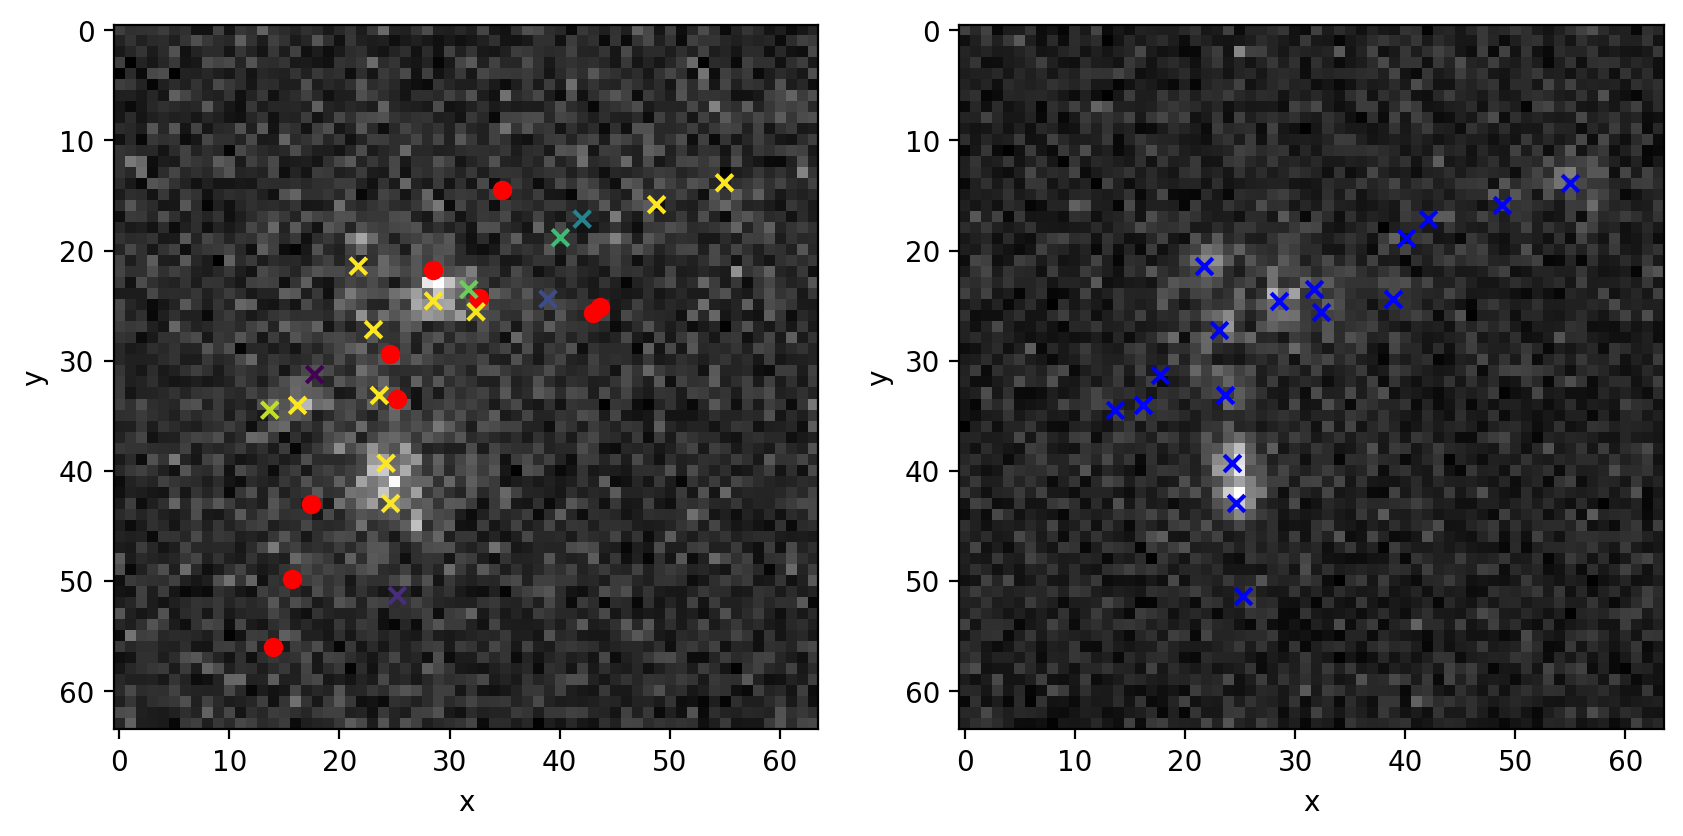

In [21]:
scen_ix = 2
f_ix = 688

frames = frame_load(next(scen.iloc[scen_ix]["path_data"].glob("*.tif")))

pos_tar = scen.iloc[scen_ix].em.iframe[f_ix].xyz_px
pos_out = scen_decode.iloc[scen_ix].em_out.iframe[f_ix].xyz_px
prob_out = scen_decode.iloc[scen_ix].em_out.iframe[f_ix].prob

f, ax = plt.subplots(1, 2, figsize=(10, 5))
plt.sca(ax[0])
decode.plot.PlotFrameCoord(
    frames[0][f_ix],
    pos_tar=pos_tar,
    pos_out=pos_out,
    phot_out=prob_out,
).plot()

plt.sca(ax[1])
decode.plot.PlotFrameCoord(
    frames[1][f_ix],
    pos_out=pos_out,
).plot()

In [27]:
scen_decode.iloc[-1].em_out.bg

tensor(111.5718)

In [32]:
scen_out = scen_decode.copy()
scen_out["path_em_out"] = scen_out.apply(lambda r:  path_out / f"{r['dataset']}_decode_fit.h5" if r["em_out"] is not None else None, axis=1)

scen_out = scen_out.drop(columns=["em", "em_out"])
scen_out

dataset  \
snr  density type  algorithm              
low  low     train DECODE     MT0_N2_LD   
             test  DECODE     MT3_N2_LD   
     high    train DECODE     MT0_N2_HD   
             test  DECODE     MT4_N2_HD   
high low     train DECODE     MT0_N1_LD   
             test  DECODE     MT1_N1_LD   
     high    train DECODE     MT0_N1_HD   
             test  DECODE     MT2_N1_HD   

                                                                      path_data  \
snr  density type  algorithm                                                      
low  low     train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE     /home/riesgroup/decode_scratch/challenge/MT3_N...   
     high    train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE     /home/riesgroup/decode_scratch/challenge/MT4_N...   
high low     train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE     /home/riesgroup/decode_scratch/challenge/MT1_N...   
     high    train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE     /home/riesgroup/decode_scratch/challenge/MT2_N...   

                                                                     path_frame  \
snr  density type  algorithm                                                      
low  low     train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE     /home/riesgroup/decode_scratch/challenge/MT3_N...   
     high    train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE     /home/riesgroup/decode_scratch/challenge/MT4_N...   
high low     train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE     /home/riesgroup/decode_scratch/challenge/MT1_N...   
     high    train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE     /home/riesgroup/decode_scratch/challenge/MT2_N...   

                                                                        path_em  \
snr  density type  algorithm                                                      
low  low     train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE                                                  None   
     high    train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE                                                  None   
high low     train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE                                                  None   
     high    train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE                                                  None   

                                                                     path_model  \
snr  density type  algorithm                                                      
low  low     train DECODE     /home/riesgroup/decode_storage/dev/lucas/train...   
             test  DECODE     /home/riesgroup/decode_storage/dev/lucas/train...   
     high    train DECODE     /home/riesgroup/decode_storage/dev/lucas/train...   
             test  DECODE     /home/riesgroup/decode_storage/dev/lucas/train...   
high low     train DECODE     /home/riesgroup/decode_storage/dev/lucas/train...   
             test  DECODE     /home/riesgroup/decode_storage/dev/lucas/train...   
     high    train DECODE     /home/riesgroup/decode_storage/dev/lucas/train...   
             test  DECODE     /home/riesgroup/decode_storage/dev/lucas/train...   

                                                                    path_em_out  
snr  density type  algorithm                                                     
low  low     train DECODE     /mnt/t1ries/users/Lucas/Manuscripts/plex/raw/b...  
             test  DECODE     /

In [33]:
# save emitters
for i, s in scen_out.join(scen_decode["em_out"]).iterrows():
    if s.em_out is None:
        continue

    s.em_out.save(s.path_em_out)

scen_out.to_pickle(path_out / "scen_out.pkl")

tensor([[ 54.4174,  46.9551,  78.9215],
        [ 85.3729,  79.1570, 106.4385],
        [  3.2356,   2.9733,  11.8021],
        ...,
        [ 54.4623,  56.7392, 168.1205],
        [ 60.6879,  64.1104,  84.2953],
        [  6.8294,   6.5146,  10.6859]])

# Deprecated Part

In [ ]:
# challenge fov filtering
xy_extent = (2.5, 60.5)
filter_fov = decode.emitter.process.EmitterFilterFoV(xy_extent, xy_extent, xy_unit="px")

In [ ]:
class _ChallengeMetric:
    def __init__(self, matcher, phot_th: float, evaluation, filter_fov, metric: str = "effcy_vol"):
        self._matcher = matcher
        self._phot_th = phot_th
        self._evaluation = evaluation
        filter_phot = decode.emitter.process.EmitterFilterGeneric(phot=lambda p: p >= s.filter_phot)
        self._filter = decode.evaluation.filter.MatchedFilter([filter_fov, filter_phot])
        self._metric = metric

    def __call__(self, em, em_ref) -> float:
        return self.forward(em, em_ref)

    def forward(self, em, em_ref) -> float:
        tp, fp, fn, tp_match = matcher.forward(em, em_ref)
        # tp = patch_for_eval(tp)
        tp, fp, fn, tp_match = self._filter.forward(tp, fp, fn, tp_match)
        eval = self._evaluation.forward(tp, fp, fn, tp_match)
        return -eval[self._metric]

In [ ]:
search = pd.DataFrame(index=scen_decode.index)
search["prob"] = 0.5
search["xyz_sig_lat_nm"] = None
search["xyz_sig_ax_nm"] = None
search["metric"] = None

search["filter_phot"] = None
search.at["low", "filter_phot"] = 100.
search.at["high", "filter_phot"] = 1000.

import skopt

space = {
    "xyz_sig_lat_nm": skopt.space.Real(10., 200.),
    # "xyz_sig_ax_nm": skopt.space.Real(20., 300.),
}

filter_fac = decode.evaluation.optimize.FilterGenerator({
    "xyz_sig_lat_nm": "less",
    # "xyz_sig_ax_nm": "less"
})


for i, s in tqdm(search.join(scen_decode).iterrows(), total=len(search)):
    em = s.em_out
    em_gt = s.em
    if em is None:
        continue

    # pre-filter
    if s.prob is not None:
        em = em[em.prob >= s.prob]
    if s.xyz_sig_lat_nm is not None:
        em = em[em.xyz_sig_lat_nm <= s.xyz_sig_lat_nm]
    if s.xyz_sig_ax_nm is not None:
        em = em[em.xyz_sig_ax_nm <= s.xyz_sig_ax_nm]

    metric = _ChallengeMetric(matcher, s.filter_phot, ev, filter_fov=filter_fov, metric="effcy_vol")
    opt = decode.evaluation.optimize.Optimizer(
        metric=metric,
        filter_fac=filter_fac,
        space=space,
        opt=decode.evaluation.optimize.wrap_skopt_functional("gp_minimize", n_calls=20, random_state=42),
        )
    param, m = opt.fit(em, em_gt)

    for k, v in param.items():
        search.at[i, k] = v
    search.at[i, "metric"] = m

search


In [ ]:
scen_pred = pd.concat([scen_decode, scen_smap.drop(columns=["path_em"])], axis=0)
scen_pred

In [ ]:
# conversion (convert all to challenge standard)
scen_pred_cvt = scen_pred.copy()

for i, r in scen_pred_cvt.iterrows():
    if r["em_out"] is None:
        continue

    em = r["em_out"].clone()
    match i[-1]:
        case "DECODE":
            em = decode.evaluation.challenge.convert.decode_to_chall(em)
            em.xyz_nm -= torch.tensor([ 5.45,  5.45, -10.45])
        case "SMAP":
            # em.xyz_px = em.xyz_px - torch.tensor([65., 0., 0.])
            em.frame_ix = em.frame_ix + 1
        case _:
            raise ValueError
    scen_pred_cvt.at[i, "em_out"] = em

scen_pred_cvt


In [ ]:
em_filters = scen_pred_cvt.copy()
em_filters["filter_prob"] = 0.6
em_filters["filter_sigma"] = None

em_filters["filter_phot"] = None
em_filters.at["low", "filter_phot"] = 100.
em_filters.at["high", "filter_phot"] = 1000.

em_filters

In [ ]:
def patch_for_eval(tp):
    tp = tp.clone()
    tp.phot = tp.phot / 0.684
    # tp.phot = tp.phot.sum(-1)
    return tp


evals = []
matches = []

for i, s in tqdm(em_filters.iterrows(), total=len(em_filters)):
    if (s.em_out is None) or (s.em is None):
        matches.append(None)
        evals.append(None)
        continue

    em_fil = s.em_out.clone()
    match i[-1]:
        case "DECODE":
            if (p := s["filter_prob"]) is not None:
                em_fil = em_fil[em_fil.prob > p]
            if (sig := s["filter_sigma"]) is not None:
                em_fil = em_fil[em_fil.xyz_sig_tot_nm < sig]
        case "SMAP":
            pass
        case _:
            raise ValueError(f"Unknown algorithm {i[-1]}")

    match = matcher.forward(em_fil, s.em)
    matches.append(match)

    tp, fp, fn, tp_match = match.tp, match.fp, match.fn, match.tp_match
    tp = patch_for_eval(tp)

    # construct challenge filter
    filter_phot = decode.emitter.process.EmitterFilterGeneric(phot=lambda p: p >= s.filter_phot)
    filter = decode.evaluation.filter.MatchedFilter([filter_fov, filter_phot])
    tp, fp, fn, tp_match = filter.forward(tp, fp, fn, tp_match)

    evals.append(ev.forward(tp, fp, fn, tp_match))

matches = pd.DataFrame([m._asdict() if m is not None else {} for m in matches], index=em_filters.index)
evals = pd.DataFrame([{} if r is None else r for r in evals], index=em_filters.index)


In [ ]:
# omit all nan cols
evals = evals.dropna(axis=1, how="all")
evals

In [ ]:
scen_decode

In [ ]:
ix = 4
em_tar = matches.iloc[ix].tp_match
em_tar.bg = torch.ones_like(em_tar.phot)

em_out = matches.iloc[ix].tp

decode.evaluation.predict_dist.deviation_dist(em_out.phot, em_tar.phot)
# plt.scatter(em_tar.phot, em_out.phot.sum(1))

ax = plt.gca()

# # plot linear
xlim = ax.get_xlim()
x = torch.linspace(*xlim, 100)
# plt.plot(x, x, "k--")
plt.plot(x, x * 0.684, "r--")

ax.set_xlim(xlim)

plt.show()

decode.evaluation.predict_dist.deviation_dist(em_out.xyz_nm[:, 2], em_tar.xyz_nm[:, 2])
plt.show()

plt.scatter(em_tar.xyz_nm[:, 2], em_out.xyz_nm[:, 2], s=1, color="k", marker=".", facecolors="k", edgecolors="none")
xlim = [-800., 800]
x = torch.linspace(*xlim, 100)
plt.plot(x, x, "r-")
plt.ylabel("Predicted z [nm]")
plt.xlabel("Target z [nm]")

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# plot all inputs and raw outputs
f_ix = 13

f, axs = plt.subplots(ncols=4, nrows=3, figsize=(14, 8))
for i, ax in enumerate(axs.flatten()):
    x = logger.model_in[0][f_ix]
    if i >= x.shape[0]:
        ax.axis("off")
        continue
    im = ax.imshow(x[i])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im, cax=cax)

plt.tight_layout()


f, axs = plt.subplots(ncols=4, nrows=3, figsize=(14, 8))
for i, ax in enumerate(axs.flatten()):
    x = logger.model_out[0][f_ix].cpu().numpy()
    if i >= x.shape[0]:
        ax.axis("off")
        continue

    im = ax.imshow(x[i])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im, cax=cax)
plt.tight_layout()

# DEBUGGING SECTION

In [ ]:
scen_pred_cvt

In [ ]:
# debugging
em_smap = scen_pred_cvt.iloc[4].em_out
em = scen_pred_cvt.iloc[4].em

renderer = decode.renderer.renderer.Renderer2D(
    xextent=(0., 128*100.),
    yextent=(100., 64*100.),
    colextent=[-500,500],
    px_size=10.,
    sigma_blur=10.,
    rel_clip=0.05,
    contrast=2,
    cmap="turbo",
)

plt.imshow(renderer.forward(em))
plt.show()

plt.imshow(renderer.forward(tp))
plt.show()

In [ ]:
tp = matches.iloc[4].tp
tp_match = matches.iloc[4].tp_match

diff = tp.xyz_nm - tp_match.xyz_nm
diff.median(0)

In [ ]:
tpf, *_, tp_matchf = filter.forward(tp, tp[0], tp[0], tp_match)

In [ ]:
plt.scatter(tp_matchf.xyz_nm[:, 2], tpf.xyz_nm[:, 2] + 16, s=1, color="k", marker=".", facecolors="k", edgecolors="none")

# plot expected linear
ax = plt.gca()
xlim = ax.get_xlim()
x = torch.linspace(*xlim, 1000)
plt.plot(x, x, "r--")

In [ ]:
print(tpf)

In [ ]:
print(tp_matchf)